In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM

In [5]:
includet("./base.jl")

In [3]:
using UnPack, JLD2, ProgressMeter
using Base.Threads

In [4]:
using CairoMakie
using GLMakie
CairoMakie.activate!()
# display(GLMakie.Screen(), f.figure)

In [261]:
N = 50
S = N
M = N + 1
ps = gen_many_mms1(N;
    K=50.,
    #
    l=Dirac(1.),
    m=base10_lognormal(0., 0.1),
    c=base10_lognormal(0., 0.1),
    #
    k=Dirac(0.3),
    B=Binomial(N, 5 / N),
    #
    DR=Dirac(0.1)
)
check_mmicrmparams(ps)

In [262]:
u0 = zeros(S + M)
(@view u0[1:S]) .= 1.;

p = make_mmicrm_problem(ps, u0, 10000)
s = solve(p, QNDF());

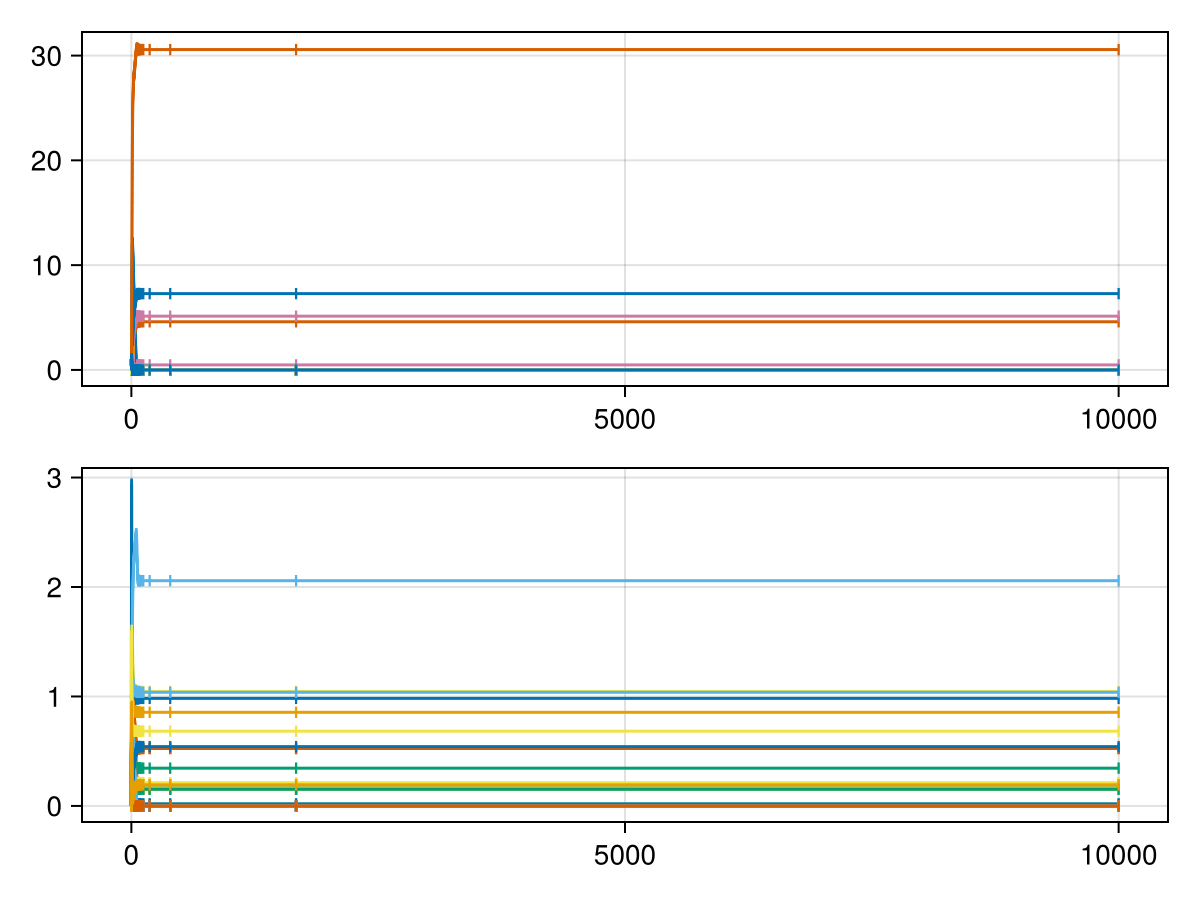

In [263]:
faa = plot_mmicrm_sol(s)
faa.figure

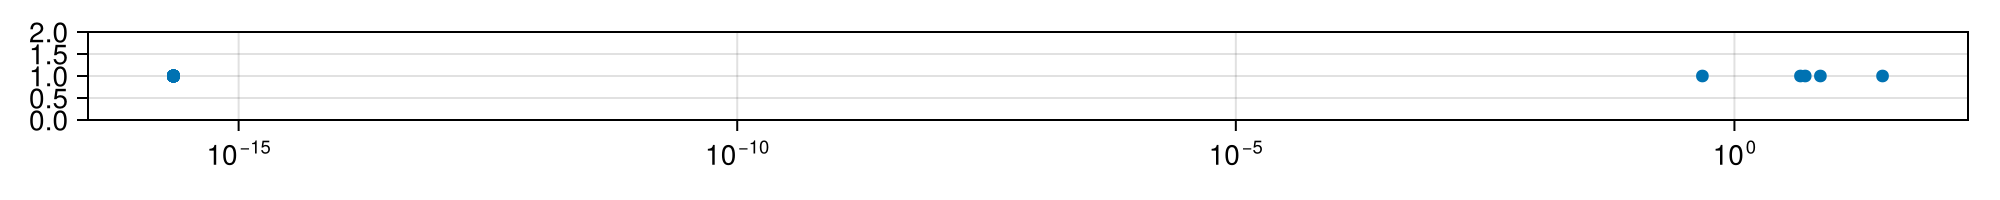

In [264]:
scatter(max.(eps(), s.u[end][1:S]), fill(1., S); axis=(; xscale=log10), figure=(; size=(1000, 100)))

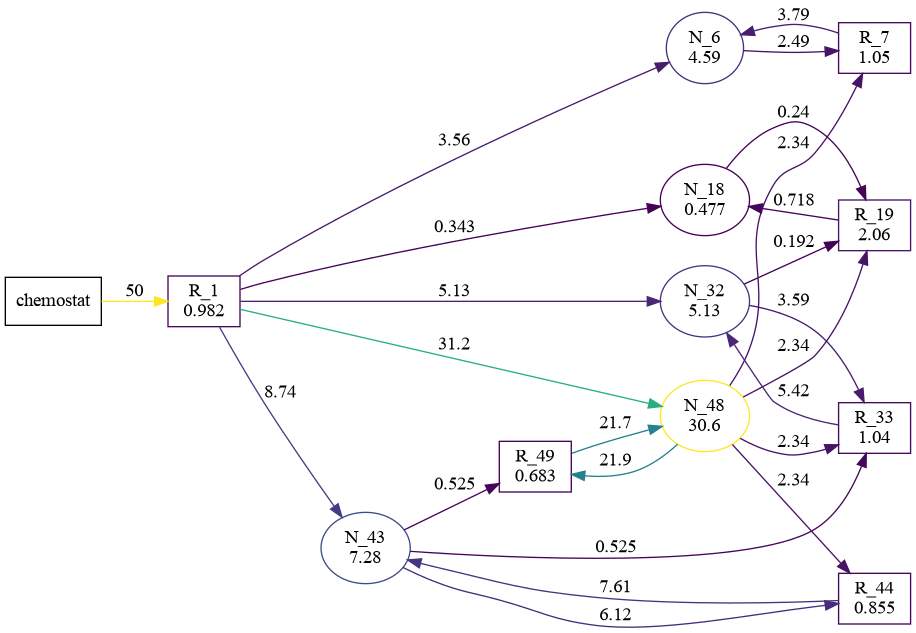

In [265]:
diagram_sfss_v3(ps, s.u[end];
    strain_threshold=0.1,
)

In [242]:
diagram_sfss_v3(ps)

┌ Error: Too many edges to draw, only drawing the first 100
└ @ SSMCMain.ModifiedMiCRM ~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/src/SSMCMain/src/ModifiedMiCRM/diagrams.jl:109
